In [1]:
from langchain_openai import AzureChatOpenAI
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from dotenv import load_dotenv
load_dotenv()

import os
from pyprojroot import here

os.chdir(here())

from coeur.score import Coeur
from coeur.utils.dataloader import UserStoryDataset

import pandas as pd
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from bert_score import score as bert_score

from datetime import datetime
from pathlib import Path
import json
import numpy as np
from scipy.stats import spearmanr, kendalltau

# Utils

In [2]:
class Interesting(BaseModel):
     interesting: bool = Field(
        description="Indicates whether the input text is valuable to write a user story or not. True if it is valuable, False otherwise."
    )

class UserStory(BaseModel):
    description: str = Field(
        min_length=20,
        # Looser pattern: just requires "As a" start and "I want" somewhere in the text
        # pattern=r"^As an? .+",
        examples=[
            "As a user, I want to log in, so that I can access my profile.",
            "As a product owner, I want to prioritize the backlog, so that the team works on the most valuable tasks."
        ],
        description="A user story is a description of a feature from an end-user perspective." + \
            "It should follow the 'As a [role], I want [feature], so that [benefit]' format." + \
            "Additionnaly, it should be between 20 and 500 characters long." 
    )

In [3]:
MAX_RETRIES = 5

def generate_B_alt(dataset: UserStoryDataset, llm: AzureChatOpenAI, prompt: str = ""):
    y_pred = []
    for i in tqdm(range(len(dataset))):
        specs, user_story, related_user_stories, epic = dataset[i][0], dataset[i][1], dataset[i][2], dataset[i][3]

        retries = 0
        response = None
        while retries < MAX_RETRIES:
            try:
                response = llm.with_structured_output(UserStory).invoke(
                    prompt.format(
                        epic=epic,
                        specs=specs,
                        related_user_stories=related_user_stories
                    )
                )
                break  # Success - exit retry loop
            except Exception as e:
                retries += 1
                print(f"User Story Generation Error (attempt {retries}/{MAX_RETRIES}): {e}")
                if retries >= MAX_RETRIES:
                    # Fallback: generate without structured output and format manually
                    print(f"Warning: Max retries reached for story {i}. Using raw LLM output.")
                    raw_response = llm.invoke(
                        prompt.format(
                            epic=epic,
                            specs=specs,
                            related_user_stories=related_user_stories
                        )
                    )
                    # Try to extract/format a user story from the raw response
                    raw_text = raw_response.content.strip()
                    if not raw_text.startswith("As a"):
                        raw_text = f"As a user, I want {raw_text[:200]}"
                    response = UserStory.model_construct(description=raw_text)

        y_pred.append({"epic": epic, "user_story": response.description, "true_user_story": user_story})
    B_pred = pd.DataFrame(y_pred)
    return B_pred

In [4]:
def iterative_coeur(R: str, B: pd.DataFrame, cs_offset=10, sigma="ROUGE-2 Precision", l="s"):
    # Iterative Calculation
    results = []
    coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True)

    for i in tqdm(range(cs_offset, len(B) + 1)):
        current_backlog = B.iloc[:i]
        
        scores = coeur.score(R=R, B=current_backlog, sigma=sigma, l=l)
        scores['n_stories'] = i
        results.append(scores)
        
    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    return df_results

def plot_iterative_coeur(df_results):
    plt.figure(figsize=(10, 6))
    plt.plot(df_results['n_stories'], df_results['COEUR'], label='COEUR', marker='o', markersize=3)
    plt.plot(df_results['n_stories'], df_results['Cohesion'], label='Cohesion', linestyle='--')
    plt.plot(df_results['n_stories'], df_results['Exhaustiveness'], label='Exhaustiveness', linestyle='--')

    plt.xlabel('Number of User Stories')
    plt.ylabel('Score')
    plt.title('COEUR Evolution with Increasing Backlog Size')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_multiple_iterative_coeur(mean_results, std_results):
    plt.figure(figsize=(10, 6))
    plt.plot(mean_results['n_stories'], mean_results['COEUR'], label='COEUR', marker='o', markersize=3)
    plt.fill_between(mean_results['n_stories'],
                     mean_results['COEUR'] - std_results['COEUR'],
                     mean_results['COEUR'] + std_results['COEUR'],
                     alpha=0.2)

    plt.plot(mean_results['n_stories'], mean_results['Cohesion'], label='Cohesion', linestyle='--')
    plt.fill_between(mean_results['n_stories'],
                     mean_results['Cohesion'] - std_results['Cohesion'],
                     mean_results['Cohesion'] + std_results['Cohesion'],
                     alpha=0.2)

    plt.plot(mean_results['n_stories'], mean_results['Exhaustiveness'], label='Exhaustiveness', linestyle='--')
    plt.fill_between(mean_results['n_stories'],
                     mean_results['Exhaustiveness'] - std_results['Exhaustiveness'],
                     mean_results['Exhaustiveness'] + std_results['Exhaustiveness'],
                     alpha=0.2)

    plt.xlabel('Number of User Stories')
    plt.ylabel('Score')
    plt.title('COEUR Evolution with Increasing Backlog Size')
    plt.legend()
    plt.grid(True)
    plt.show()

def load_results(dataset_name: str, strategy_name: str):
    results_dir = os.path.join('experiments', 'llm_validation', 'output', dataset_name)

    mean_path = os.path.join(results_dir, f'mean_results_{strategy_name}.csv')
    std_path = os.path.join(results_dir, f'std_results_{strategy_name}.csv')

    mean_results = pd.read_csv(mean_path)
    std_results = pd.read_csv(std_path)
    return mean_results, std_results

def compare_coeur_strategies(dataset_name: str, strategy_names: list[str], metric: str = "COEUR"):
    plt.figure(figsize=(10, 6))

    for strategy_name in strategy_names:
        mean_results, std_results = load_results(dataset_name, strategy_name)
        
        plt.plot(mean_results['n_stories'], mean_results[metric], label=strategy_name, marker='o', markersize=3)
        plt.fill_between(mean_results['n_stories'],
                         mean_results[metric] - std_results[metric],
                         mean_results[metric] + std_results[metric],
                         alpha=0.2)

    plt.xlabel('Number of User Stories')
    plt.ylabel(f'{metric} Score')
    plt.title(f'Comparison of {metric} Evolution Across Strategies')
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
def evaluate_and_plot(B_pred: pd.DataFrame, R: str, B_true: pd.DataFrame = None):
    # Imports
    from rouge_score import rouge_scorer
    import numpy as np
    
    # 1. ROUGE Scores Calculation (Row-by-row: Generated vs True User Story)
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = []
    
    for _, row in B_pred.iterrows():
        # Reference is true_user_story, Hypothesis is generated user_story
        scores = scorer.score(row['true_user_story'], row['user_story'])
        rouge_scores.append({
            'rouge1': scores['rouge1'].fmeasure,
            'rouge2': scores['rouge2'].fmeasure,
            'rougeL': scores['rougeL'].fmeasure
        })
    
    avg_rouge = pd.DataFrame(rouge_scores).mean()
    
    # 2. COEUR Scores Calculation (Full Backlog: Generated vs Specs)
    coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True)
    
    # Calculate COEUR for generated backlog
    scores_pred = coeur.score(R=R, B=B_pred, sigma="ROUGE-2 F1", l="b")
    
    # Calculate COEUR for true backlog if provided for comparison
    scores_true = None
    if B_true is not None:
         scores_true = coeur.score(R=R, B=B_true, sigma="ROUGE-2 F1", l="b")

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Helper for bar labels
    def autolabel(ax, rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    # --- Plot 1: ROUGE Scores ---
    rouge_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
    rouge_values = [avg_rouge['rouge1'], avg_rouge['rouge2'], avg_rouge['rougeL']]
    
    x_rouge = np.arange(len(rouge_labels))
    width = 0.35
    
    rects_rouge = ax1.bar(x_rouge, rouge_values, width * 1.5, label='Generated vs True', color='#1f77b4')
    
    ax1.set_ylabel('F1 Score')
    ax1.set_title('Evaluation 1: Textual Similarity\n(Generated Story vs True Story)')
    ax1.set_xticks(x_rouge)
    ax1.set_xticklabels(rouge_labels)
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    autolabel(ax1, rects_rouge)

    # --- Plot 2: COEUR Scores ---
    coeur_labels = ['COEUR', 'Cohesion', 'Exhaustiveness']
    pred_values = [scores_pred['COEUR'], scores_pred['Cohesion'], scores_pred['Exhaustiveness']]
    
    x_coeur = np.arange(len(coeur_labels))
    
    if scores_true:
        true_values = [scores_true['COEUR'], scores_true['Cohesion'], scores_true['Exhaustiveness']]
        rects1 = ax2.bar(x_coeur - width/2, pred_values, width, label='Generated Backlog')
        rects2 = ax2.bar(x_coeur + width/2, true_values, width, label='Ground Truth Backlog', color='lightgray')
        ax2.legend() 
        autolabel(ax2, rects1)
        autolabel(ax2, rects2)
    else:
        rects = ax2.bar(x_coeur, pred_values, width, label='Generated Backlog')
        autolabel(ax2, rects)
        
    ax2.set_xticks(x_coeur)
    ax2.set_xticklabels(coeur_labels)
    ax2.set_title('Evaluation 2: Backlog Quality Metrics\n(Backlog vs Specs)')
    ax2.set_ylabel('Score')
    ax2.set_ylim(0, 1.05)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return avg_rouge, scores_pred


def evaluate_and_compare(strategies: dict, R: str, B_true: pd.DataFrame = None,
                         sigma="ROUGE-2 F1", l="b", lmbd=0.75, use_bertscore=True):
    """
    Evaluate and compare multiple user story generation strategies.
    
    Args:
        strategies: Dictionary of {name: DataFrame} with generated backlogs
        R: Reference specifications text
        B_true: Ground truth backlog DataFrame (optional)
        sigma: Similarity metric for COEUR scoring
        l: Level parameter for COEUR scoring
        lmbd: Lambda parameter for COEUR scoring
        use_bertscore: Whether to compute BERTScore (slower but more semantic)
    
    Returns:
        Tuple of (rouge_results, bertscore_results, coeur_results)
    """
    # Imports
    from rouge_score import rouge_scorer
    import numpy as np
    
    # Initialize scorers
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    coeur_scorer = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True, penalize_duplicates=True)
    
    rouge_results = {}
    bertscore_results = {}
    coeur_results = {}
    
    # 1. Calculation Loop
    for name, B_pred in strategies.items():
        # Collect references and candidates for batch processing
        references = []
        candidates = []
        
        # ROUGE Scores
        rouge_scores = []
        for _, row in B_pred.iterrows():
            # Ensure we have a reference. Using 'true_user_story' from generate_B_alt
            ref = row.get('true_user_story', "")
            if not ref and B_true is not None:
                # Fallback if indices align
                try: ref = B_true.iloc[_]['user_story']
                except: pass
                
            if ref:
                references.append(ref)
                candidates.append(row['user_story'])
                scores = scorer.score(ref, row['user_story'])
                rouge_scores.append({
                    'rouge1': scores['rouge1'].fmeasure,
                    'rouge2': scores['rouge2'].fmeasure,
                    'rougeL': scores['rougeL'].fmeasure
                })
        
        if rouge_scores:
            rouge_results[name] = pd.DataFrame(rouge_scores).mean()
        
        # BERTScore Calculation (batch for efficiency)
        if use_bertscore and references and candidates:
            
            P, R_bert, F1 = bert_score(candidates, references, lang="en", verbose=False)
            bertscore_results[name] = {
                'precision': P.mean().item(),
                'recall': R_bert.mean().item(),
                'f1': F1.mean().item()
            }
        
        # COEUR Scores
        coeur_results[name] = coeur_scorer.score(R=R, B=B_pred, sigma=sigma, l=l, lmbd=lmbd)
        
    # Ground Truth COEUR
    coeur_true = None
    if B_true is not None:
         coeur_true = coeur_scorer.score(R=R, B=B_true, sigma=sigma, l=l, lmbd=lmbd)

    # 2. Visualization
    n_plots = 3 if use_bertscore and bertscore_results else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 8))
    if n_plots == 2:
        ax1, ax2 = axes
        ax_bert = None
    else:
        ax1, ax_bert, ax2 = axes
    
    size_offset = 4
    # Set global font sizes
    plt.rc('font', size=12+size_offset)
    plt.rc('axes', titlesize=16+size_offset)
    plt.rc('axes', labelsize=14+size_offset)
    plt.rc('xtick', labelsize=12+size_offset)
    plt.rc('ytick', labelsize=12+size_offset)
    plt.rc('legend', fontsize=12+size_offset)

    def autolabel(ax, rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', rotation=90, fontsize=9)

    # --- Plot 1: ROUGE ---
    if rouge_results:
        metrics = ['rouge1', 'rouge2', 'rougeL']
        plot_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
        x = np.arange(len(plot_labels))
        width = 0.8 / len(strategies)
        
        for i, (name, res) in enumerate(rouge_results.items()):
            offset = width * i - width * (len(strategies) - 1) / 2
            values = [res[m] for m in metrics]
            rects = ax1.bar(x + offset, values, width, label=name)
            autolabel(ax1, rects)
            
        ax1.set_ylabel('F1 Score')
        ax1.set_title('ROUGE: Textual Similarity vs Ground Truth')
        ax1.set_xticks(x)
        ax1.set_xticklabels(plot_labels)
        ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2) 
        ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- Plot 2: BERTScore ---
    if ax_bert is not None and bertscore_results:
        metrics_bert = ['precision', 'recall', 'f1']
        plot_labels_bert = ['Precision', 'Recall', 'F1']
        x_bert = np.arange(len(plot_labels_bert))
        width_bert = 0.8 / len(strategies)
        
        for i, (name, res) in enumerate(bertscore_results.items()):
            offset = width_bert * i - width_bert * (len(strategies) - 1) / 2
            values = [res[m] for m in metrics_bert]
            rects = ax_bert.bar(x_bert + offset, values, width_bert, label=name)
            autolabel(ax_bert, rects)
            
        ax_bert.set_ylabel('Score')
        ax_bert.set_title('BERTScore: Semantic Similarity vs Ground Truth')
        ax_bert.set_xticks(x_bert)
        ax_bert.set_xticklabels(plot_labels_bert)
        ax_bert.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2) 
        ax_bert.grid(axis='y', linestyle='--', alpha=0.3)

    # --- Plot 3: COEUR ---
    metrics_c = ['COEUR', 'Cohesion', 'Exhaustiveness']
    x_c = np.arange(len(metrics_c))
    num_groups = len(strategies) + (1 if coeur_true else 0)
    width_c = 0.8 / num_groups
    
    for i, (name, res) in enumerate(coeur_results.items()):
        offset = width_c * i - width_c * (num_groups - 1) / 2
        values = [res[m] for m in metrics_c]
        rects = ax2.bar(x_c + offset, values, width_c, label=name)
        autolabel(ax2, rects)
        
    if coeur_true:
        offset = width_c * len(strategies) - width_c * (num_groups - 1) / 2
        values = [coeur_true[m] for m in metrics_c]
        rects = ax2.bar(x_c + offset, values, width_c, label='Ground Truth', color='gray', alpha=0.3, hatch='//')
        autolabel(ax2, rects)

    ax2.set_ylabel('Score')
    ax2.set_title('COEUR: Backlog Quality Metrics')
    ax2.set_xticks(x_c)
    ax2.set_xticklabels(metrics_c)
    ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    return rouge_results, bertscore_results, coeur_results

In [6]:
def load_experiment(experiment_folder):
    path = Path(experiment_folder)
    results = {}
    
    # Load all json files that aren't metadata
    for file in path.glob("strategy_*.json"):
        strategy_name = file.stem.replace("strategy_", "")
        results[strategy_name] = pd.read_json(file)
    desired_order = ["context_related", "context_only", "related_only", "no_context_no_epic"]
    results = {k: results[k] for k in desired_order if k in results}

    return results

def save_strategies(strategies, prompts, experiment_folder, experiment_name=None):
    """
    Saves a dictionary of strategy DataFrames and their corresponding prompts.
    """
    # 1. Create a unique folder for this run
    if experiment_name is None:
        experiment_name = f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    base_path = Path("experiments/llm_validation/output") / experiment_folder / experiment_name
    base_path.mkdir(parents=True, exist_ok=True)
    
    # 2. Save each strategy DataFrame
    for name, df in strategies.items():
        # Use Parquet or JSONL for text data (CSVs can be buggy with long text)
        file_path = base_path / f"strategy_{name}.json"
        df.to_json(file_path, orient="records", indent=4)
        print(f"Saved strategy '{name}' to {file_path}")

    # 3. Save the prompts (Metadata) so you know what generated the data
    metadata = {
        "timestamp": datetime.now().isoformat(),
        "prompts": prompts,
        "strategy_names": list(strategies.keys())
    }
    
    with open(base_path / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=4)
    
    print(f"\n✅ Experiment saved in: {base_path}")
    return base_path

In [7]:
def plot_comparative_results(datasets_results: dict, metric: str = "COEUR"):
    """
    Plots comparative results for ROUGE, BERTScore and COEUR metrics.
    Grouped by Dataset, with Strategies displayed as side-by-side vertical bars for easy comparison.
    Strategies are ordered by decreasing information: context_related > context_only > related_only > no_context_no_epic
    
    Args:
        datasets_results: Dict of {dataset_name: (rouge_res, bertscore_res, coeur_res)}
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    # 1. Prepare Data
    metrics_data = []
    has_bertscore = False
    
    for dataset_name, results_tuple in datasets_results.items():
        # Handle both old format (rouge, coeur) and new format (rouge, bertscore, coeur)
        if len(results_tuple) == 3:
            rouge_res, bertscore_res, coeur_res = results_tuple
            has_bertscore = has_bertscore or bool(bertscore_res)
        else:
            rouge_res, coeur_res = results_tuple
            bertscore_res = {}
            
        for strategy_name, scores in rouge_res.items():
            r1 = scores['rouge1'] if 'rouge1' in scores else 0
            r2 = scores['rouge2'] if 'rouge2' in scores else 0
            rl = scores['rougeL'] if 'rougeL' in scores else 0
            
            metrics_data.append({'Dataset': dataset_name, 'Strategy': strategy_name, 'Metric Type': 'ROUGE', 'Metric': 'ROUGE-1', 'Score': r1})
            metrics_data.append({'Dataset': dataset_name, 'Strategy': strategy_name, 'Metric Type': 'ROUGE', 'Metric': 'ROUGE-2', 'Score': r2})
            metrics_data.append({'Dataset': dataset_name, 'Strategy': strategy_name, 'Metric Type': 'ROUGE', 'Metric': 'ROUGE-L', 'Score': rl})
        
        # BERTScore metrics
        for strategy_name, scores in bertscore_res.items():
            bp = scores.get('precision', 0)
            br = scores.get('recall', 0)
            bf1 = scores.get('f1', 0)
            
            metrics_data.append({'Dataset': dataset_name, 'Strategy': strategy_name, 'Metric Type': 'BERTScore', 'Metric': 'BERTScore-P', 'Score': bp})
            metrics_data.append({'Dataset': dataset_name, 'Strategy': strategy_name, 'Metric Type': 'BERTScore', 'Metric': 'BERTScore-R', 'Score': br})
            metrics_data.append({'Dataset': dataset_name, 'Strategy': strategy_name, 'Metric Type': 'BERTScore', 'Metric': 'BERTScore-F1', 'Score': bf1})
            
        for strategy_name, scores in coeur_res.items():
            for m in ['COEUR', 'Cohesion', 'Exhaustiveness']:
                val = scores[m] if m in scores else 0
                metrics_data.append({'Dataset': dataset_name, 'Strategy': strategy_name, 'Metric Type': 'Quality', 'Metric': m, 'Score': val})
                
    df = pd.DataFrame(metrics_data)
    
    # 2. Setup Figure - 3x3 if BERTScore present, else 2x3
    n_rows = 3 if has_bertscore else 2
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
    
    datasets = list(datasets_results.keys())
    
    # Define strategy order: decreasing information
    strategy_order = ['context_related', 'context_only', 'related_only', 'no_context_no_epic']
    # Filter to only include strategies present in data
    strategies = [s for s in strategy_order if s in df['Strategy'].unique()]
    
    # Color palette: gradient from rich (high info) to pale (low info)
    strategy_colors = {
        'context_related': '#1a5276',    # Dark blue - full information
        'context_only': '#2e86ab',        # Medium blue - context only
        'related_only': '#a3c1da',        # Light blue - epic only  
        'no_context_no_epic': '#d5dbdb'   # Gray - no information
    }
    
    # Strategy display names for legend
    strategy_labels = {
        'context_related': 'Context + Epic',
        'context_only': 'Context Only',
        'related_only': 'Epic Only',
        'no_context_no_epic': 'No Context'
    }
    
    # 3. Helper function for vertical grouped bar chart
    def plot_metric_comparison(ax, df_subset, metric_name, title, ylim_max=1.0):
        n_datasets = len(datasets)
        n_strategies = len(strategies)
        
        x = np.arange(n_datasets)
        bar_width = 0.8 / n_strategies
        
        for i, strategy in enumerate(strategies):
            values = []
            for ds in datasets:
                val = df_subset[(df_subset['Dataset'] == ds) & 
                                (df_subset['Strategy'] == strategy) & 
                                (df_subset['Metric'] == metric_name)]['Score']
                values.append(val.values[0] if len(val) > 0 else 0)
            
            offset = (i - n_strategies / 2 + 0.5) * bar_width
            bars = ax.bar(x + offset, values, bar_width, 
                         label=strategy_labels.get(strategy, strategy), 
                         color=strategy_colors.get(strategy, '#888888'), 
                         edgecolor='white', linewidth=0.8)
            
            # Add value labels on top of bars
            for bar, val in zip(bars, values):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                           f'{val:.2f}', ha='center', va='bottom', fontsize=9, 
                           color='#333', rotation=0)
        
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, fontsize=12)
        ax.set_ylim(0, ylim_max)
        ax.set_ylabel("Score", fontsize=11)
        ax.set_title(title, fontweight='bold', pad=15, fontsize=13)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # 4. Plot grid
    df_rouge = df[df['Metric Type'] == 'ROUGE']
    df_bertscore = df[df['Metric Type'] == 'BERTScore']
    df_quality = df[df['Metric Type'] == 'Quality']
    
    # Row 1: ROUGE metrics
    plot_metric_comparison(axes[0, 0], df_rouge, 'ROUGE-1', 'ROUGE-1 (Unigram Overlap)')
    plot_metric_comparison(axes[0, 1], df_rouge, 'ROUGE-2', 'ROUGE-2 (Bigram Overlap)')
    plot_metric_comparison(axes[0, 2], df_rouge, 'ROUGE-L', 'ROUGE-L (Longest Overlap)')
    
    if has_bertscore:
        # Row 2: BERTScore metrics (higher values typical, adjust ylim)
        plot_metric_comparison(axes[1, 0], df_bertscore, 'BERTScore-P', 'BERTScore Precision', ylim_max=1.0)
        plot_metric_comparison(axes[1, 1], df_bertscore, 'BERTScore-R', 'BERTScore Recall', ylim_max=1.0)
        plot_metric_comparison(axes[1, 2], df_bertscore, 'BERTScore-F1', 'BERTScore F1', ylim_max=1.0)
        # Row 3: COEUR metrics
        plot_metric_comparison(axes[2, 0], df_quality, 'COEUR', 'COEUR (Overall Quality)')
        plot_metric_comparison(axes[2, 1], df_quality, 'Cohesion', 'Cohesion')
        plot_metric_comparison(axes[2, 2], df_quality, 'Exhaustiveness', 'Exhaustiveness')
    else:
        # Row 2: COEUR metrics (no BERTScore)
        plot_metric_comparison(axes[1, 0], df_quality, 'COEUR', 'COEUR (Overall Quality)')
        plot_metric_comparison(axes[1, 1], df_quality, 'Cohesion', 'Cohesion')
        plot_metric_comparison(axes[1, 2], df_quality, 'Exhaustiveness', 'Exhaustiveness')

    # Add a shared legend at bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(strategies), 
               frameon=False, fontsize=12, bbox_to_anchor=(0.5, 0.02))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()

# Load Data

In [8]:
model_name = "mistral_small_22b"

In [9]:
SIGMA = "ROUGE-2 F1"
L = "b"
LMBD = 0.75

coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True, penalize_duplicates=True)

specs_path = os.path.join('datasets', 'trident', 'trident_specs.pdf')
backlog_path = os.path.join('datasets', 'trident', 'trident_backlog.csv')
R_TRIDENT, B_TRIDENT = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

specs_path = os.path.join('datasets', 'retro', 'retro_specs.pdf')
backlog_path = os.path.join('datasets', 'retro', 'retro_backlog.csv')
R_RETRO, B_RETRO = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

specs_path = os.path.join('datasets', 'alfred', 'alfred_specs.pdf')
backlog_path = os.path.join('datasets', 'alfred', 'alfred_backlog.csv')
R_ALFRED, B_ALFRED = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


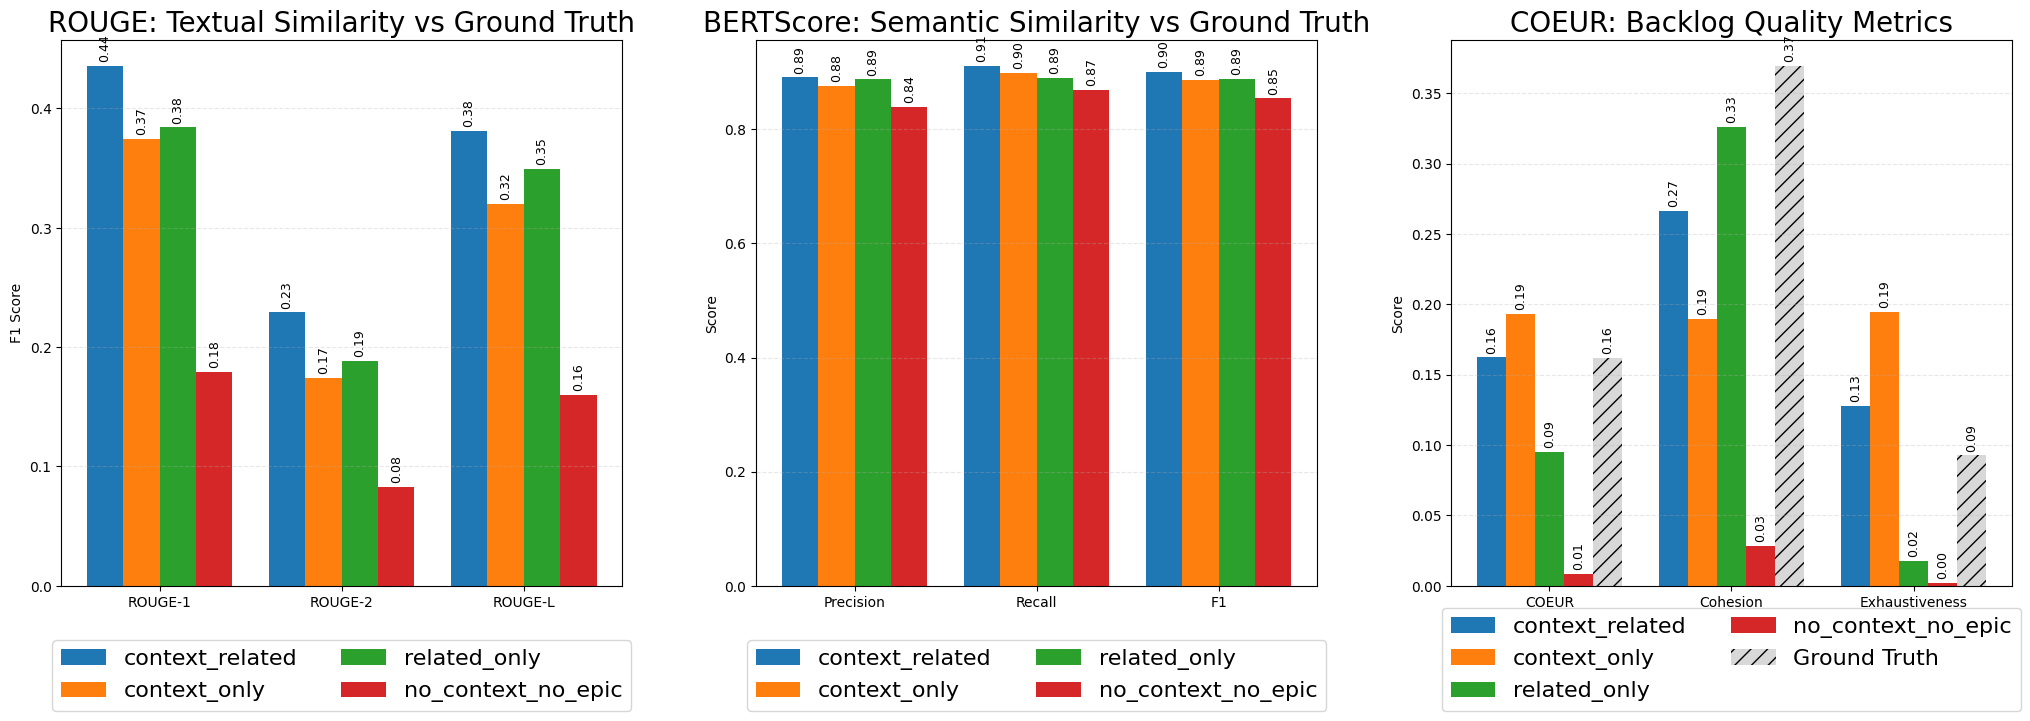

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


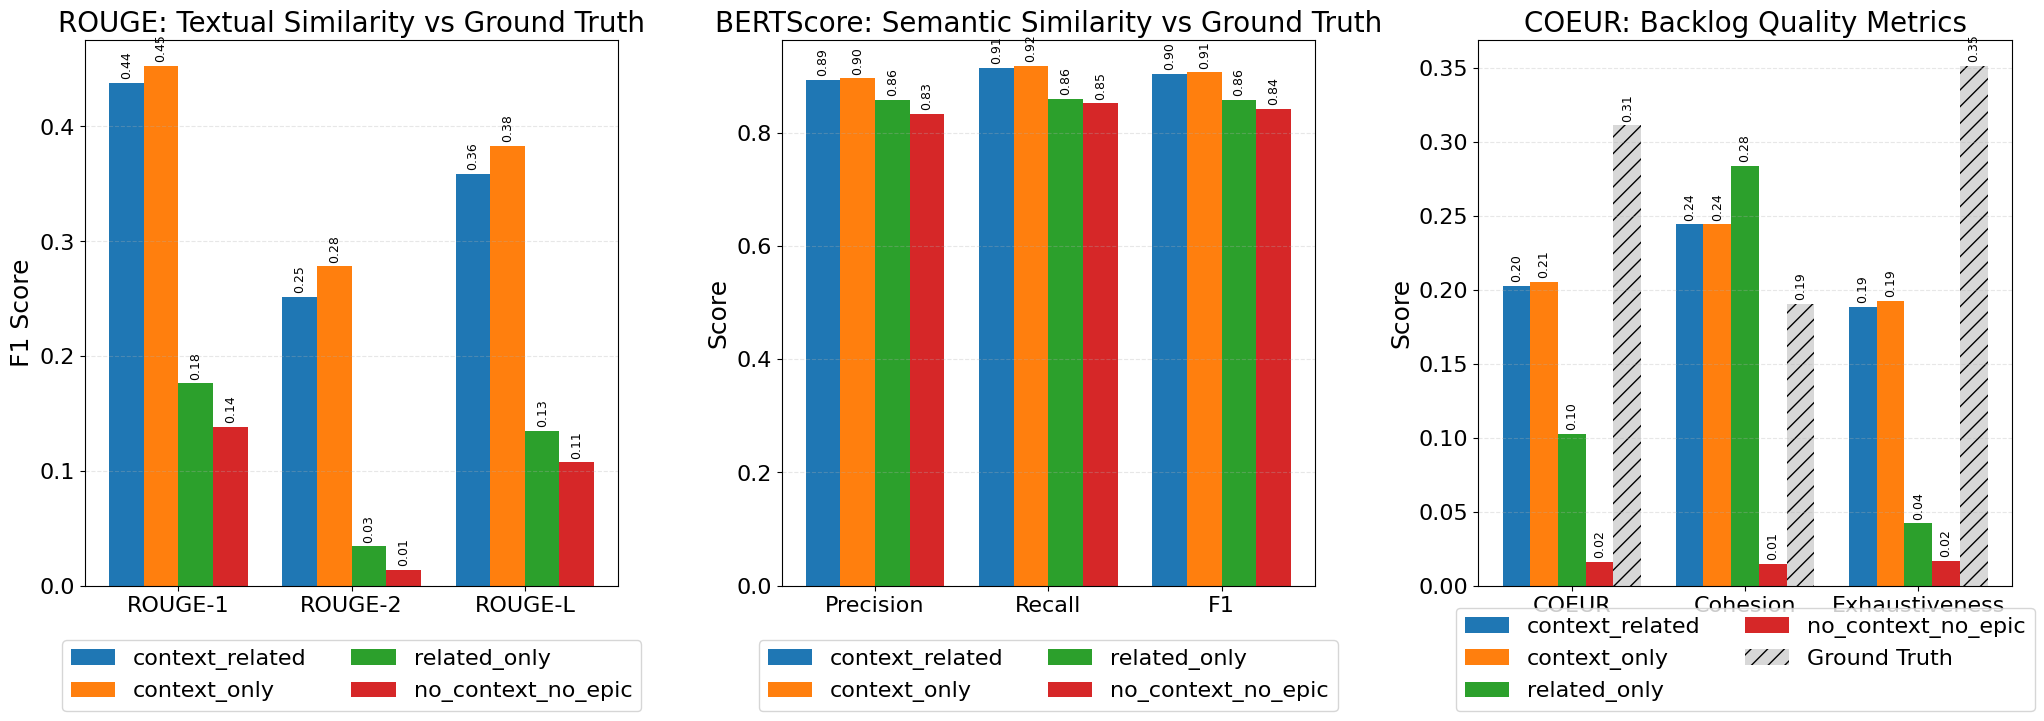

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


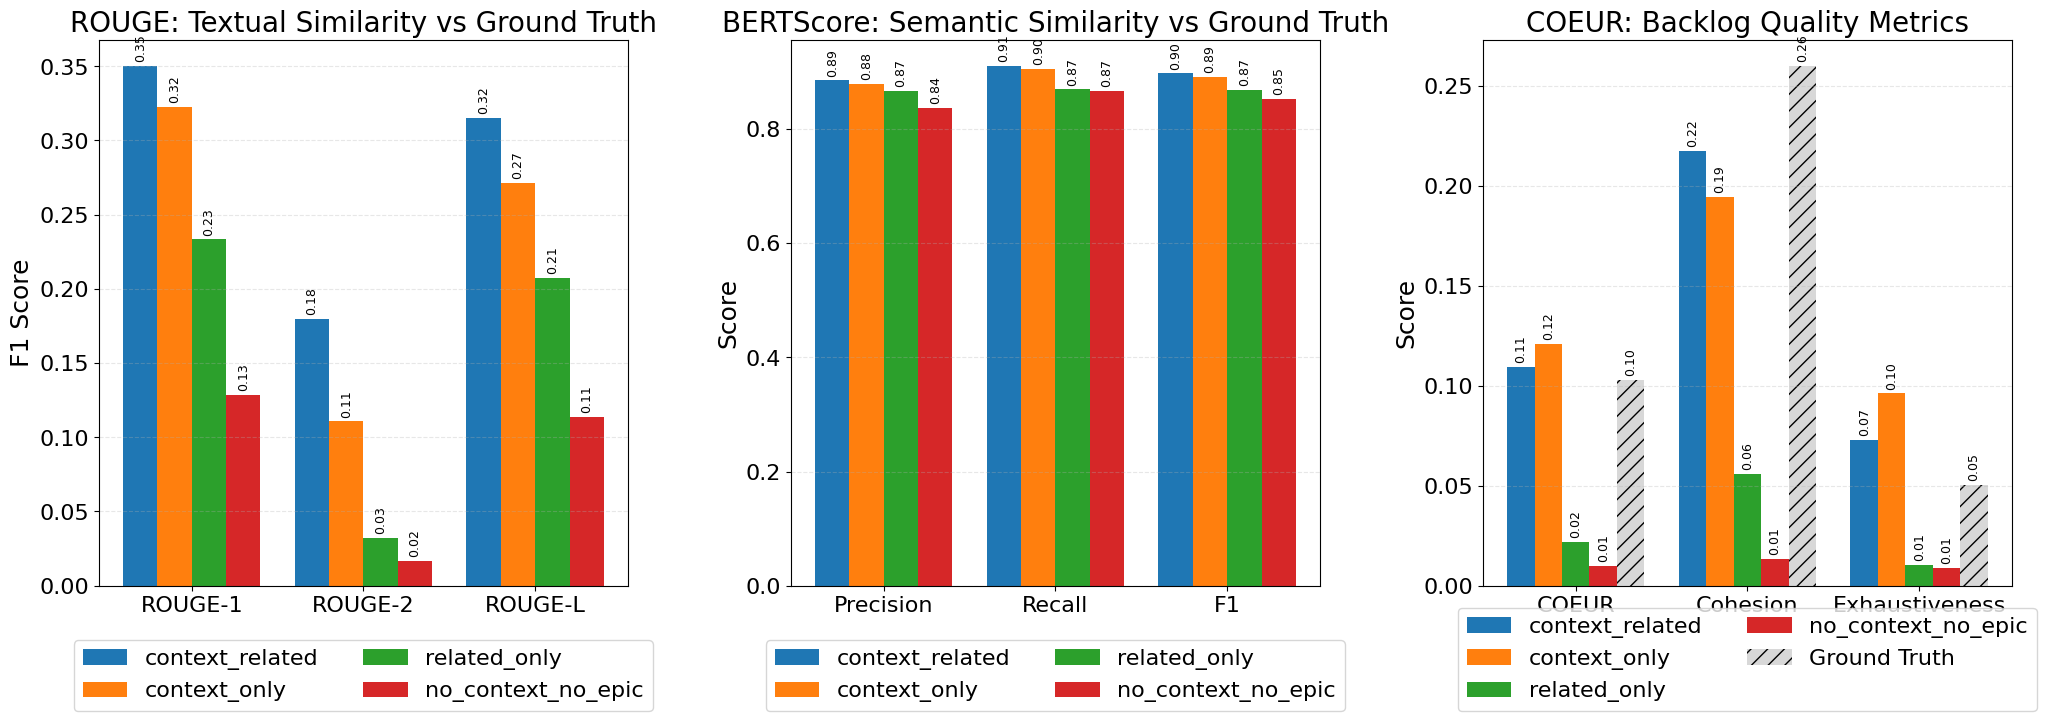

In [10]:
trident_strategies = load_experiment(f"experiments/llm_validation/output/icl_trident/{model_name}")
trident_rouge, trident_bertscore, trident_coeur = evaluate_and_compare(trident_strategies, R_TRIDENT, B_true=B_TRIDENT,
                         sigma=SIGMA, l=L, lmbd=LMBD)
retro_strategies = load_experiment(f"experiments/llm_validation/output/icl_retro/{model_name}")
retro_rouge, retro_bertscore, retro_coeur = evaluate_and_compare(retro_strategies, R_RETRO, B_true=B_RETRO,
                         sigma=SIGMA, l=L, lmbd=LMBD)
alfred_strategies = load_experiment(f"experiments/llm_validation/output/icl_alfred/{model_name}")
alfred_rouge, alfred_bertscore, alfred_coeur = evaluate_and_compare(alfred_strategies, R_ALFRED, B_true=B_ALFRED,
                         sigma=SIGMA, l=L, lmbd=LMBD)

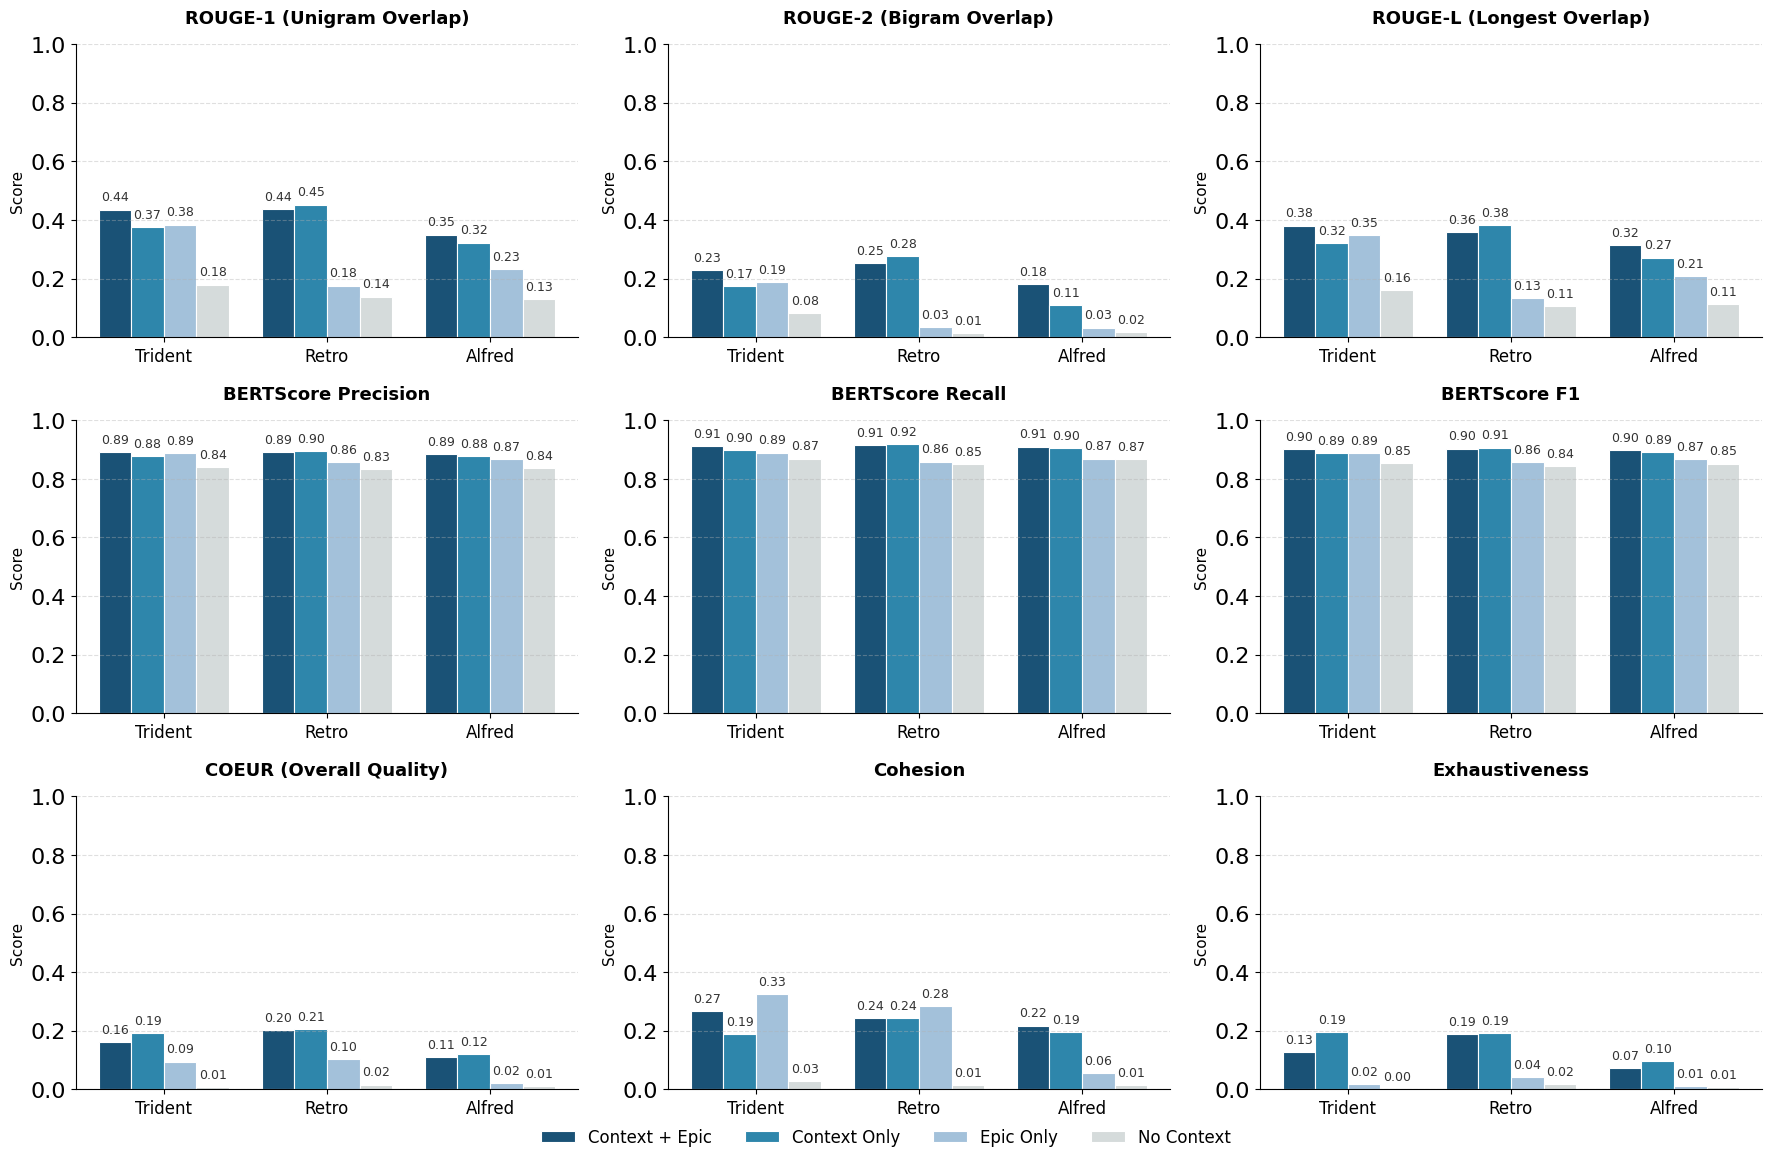

In [11]:
datasets_results = {
    "Trident": (trident_rouge, trident_bertscore, trident_coeur),
    "Retro": (retro_rouge, retro_bertscore, retro_coeur),
    "Alfred": (alfred_rouge, alfred_bertscore, alfred_coeur)
}

plot_comparative_results(datasets_results, metric="COEUR")

In [12]:
def spearman_correlation(datasets_results, metric1: str = "COEUR", metric2: str = "rouge2", verbose=False):
    
    metric1_values = []
    metric2_values = []
    
    bert_cats = {
        "p": "precision",
        "r": "recall",
        "f1": "f1"
    }

    if metric1.startswith("ROUGE-"):
        metric1 = metric1.lower().replace("-", "")
        metric1 = metric1[:-1] + metric1[-1].upper()
        m1_category = "ROUGE"
    elif metric1.startswith("BERTScore"):
        metric1 = bert_cats[metric1.split("-")[-1].lower()]
        m1_category = "BERTScore"
    else:
        m1_category = "COEUR"

    if metric2.startswith("ROUGE-"):
        metric2 = metric2.lower().replace("-", "")
        metric2 = metric2[:-1] + metric2[-1].upper()
        m2_category = "ROUGE"
    elif metric2.startswith("BERTScore"):
        metric2 = bert_cats[metric2.split("-")[-1].lower()]
        m2_category = "BERTScore"
    else:
        m2_category = "COEUR"

       
    metric_map = {
        "ROUGE": 0,
        "BERTScore": 1,
        "COEUR": 2
    }

    for dataset_name, results_tuple in datasets_results.items():
        strategies = results_tuple[0].keys()
        for strategy_name in strategies:
            m1 = results_tuple[metric_map[m1_category]][strategy_name][metric1] if strategy_name in results_tuple[metric_map[m1_category]] else None
            m2 = results_tuple[metric_map[m2_category]][strategy_name][metric2] if strategy_name in results_tuple[metric_map[m2_category]] else None
            
            if m1 is not None and m2 is not None:
                metric1_values.append(m1)
                metric2_values.append(m2)
    
    correlation, p_value = spearmanr(metric1_values, metric2_values)
    tau, tau_p_value = kendalltau(metric1_values, metric2_values)
    if verbose:
        print(f"Spearman Correlation between {metric1} and {metric2}: {correlation:.4f} (p-value: {p_value:.4f})")
        print(f"Kendall Tau Correlation between {metric1} and {metric2}: {tau:.4f} (p-value: {tau_p_value:.4f})")

    return {
        "spearman_correlation": correlation,
        "spearman_p_value": p_value,
        "kendall_tau": tau,
        "kendall_p_value": tau_p_value
    }

In [13]:
_=spearman_correlation(datasets_results, metric1="BERTScore-F1", metric2="ROUGE-2", verbose=True)
_=spearman_correlation(datasets_results, metric1="COEUR", metric2="ROUGE-2", verbose=True)

Spearman Correlation between f1 and rouge2: 0.9371 (p-value: 0.0000)
Kendall Tau Correlation between f1 and rouge2: 0.8182 (p-value: 0.0000)
Spearman Correlation between COEUR and rouge2: 0.8042 (p-value: 0.0016)
Kendall Tau Correlation between COEUR and rouge2: 0.6364 (p-value: 0.0032)


In [14]:
import pandas as pd
from scipy.stats import spearmanr, kendalltau
from IPython.display import display, HTML

def compute_correlation_table(datasets_results, rows=None, cols=None):
    """
    Compute correlation matrix between COEUR metrics and ROUGE/BERTScore metrics.
    Returns a styled pandas DataFrame.
    """

    
    if rows is None:
        # coeur_metrics = ["COEUR", "Cohesion", "Exhaustiveness"]
        coeur_metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-P", "BERTScore-R", "BERTScore-F1", "COEUR", "Cohesion", "Exhaustiveness"]
    else:
        coeur_metrics = rows
    
    if cols is None:
        other_metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-P", "BERTScore-R", "BERTScore-F1", "COEUR", "Cohesion", "Exhaustiveness"]
        # other_metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-P", "BERTScore-R", "BERTScore-F1"]
    else:
        other_metrics = cols
    
    results = []
    
    for coeur_metric in coeur_metrics:
        row = {"Metric": coeur_metric}
        for other_metric in other_metrics:
            corr_result = spearman_correlation(datasets_results, metric1=coeur_metric, metric2=other_metric, verbose=False)
            rho = corr_result["spearman_correlation"]
            p_val = corr_result["spearman_p_value"]
            
            # Format with significance markers
            if p_val < 0.001:
                sig = "***"
            elif p_val < 0.01:
                sig = "**"
            elif p_val < 0.05:
                sig = "*"
            else:
                sig = ""
            
            row[other_metric] = f"{rho:.3f}{sig}"
        results.append(row)
    
    df = pd.DataFrame(results)
    df = df.set_index("Metric")
    
    return df

def style_correlation_table(df):
    """Apply styling to the correlation table."""
    def color_correlation(val):
        try:
            num = float(val.rstrip('*'))
            if num > 0.7:
                return 'background-color: #1e8449; color: white; font-weight: bold'
            elif num > 0.5:
                return 'background-color: #27ae60; color: white'
            elif num > 0.3:
                return 'background-color: #52be80; color: #1a1a1a'
            elif num < -0.3:
                return 'background-color: #e74c3c; color: white'
            else:
                return 'background-color: #f5b041; color: #1a1a1a'
        except:
            return ''
    
    styled = df.style.map(color_correlation)\
        .set_caption("Spearman Correlation: COEUR vs ROUGE/BERTScore")\
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
            {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('padding', '8px')]},
            {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
            {'selector': 'th.row_heading', 'props': [('background-color', '#5d6d7e'), ('color', 'white')]},
        ])
    
    return styled

In [15]:

# Compute and display the correlation table
print("=" * 70)
print("Correlation Analysis: COEUR Metrics vs ROUGE/BERTScore")
print("=" * 70)
print("\nSignificance levels: * p<0.05, ** p<0.01, *** p<0.001\n")

rows = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-P", "BERTScore-R", "BERTScore-F1", "COEUR", "Cohesion", "Exhaustiveness"]
cols = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-P", "BERTScore-R", "BERTScore-F1", "COEUR", "Cohesion", "Exhaustiveness"]

correlation_df = compute_correlation_table(datasets_results, rows=rows, cols=cols)
styled_table = style_correlation_table(correlation_df)
display(styled_table)

Correlation Analysis: COEUR Metrics vs ROUGE/BERTScore

Significance levels: * p<0.05, ** p<0.01, *** p<0.001



,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore-P,BERTScore-R,BERTScore-F1,COEUR,Cohesion,Exhaustiveness
Metric,,,,,,,,,
ROUGE-1,1.000***,0.965***,0.986***,0.965***,0.916***,0.930***,0.839***,0.643*,0.769**
ROUGE-2,0.965***,1.000***,0.965***,0.965***,0.916***,0.937***,0.804**,0.692*,0.727**
ROUGE-L,0.986***,0.965***,1.000***,0.965***,0.923***,0.930***,0.818**,0.650*,0.748**
BERTScore-P,0.965***,0.965***,0.965***,1.000***,0.937***,0.979***,0.832***,0.713**,0.727**
BERTScore-R,0.916***,0.916***,0.923***,0.937***,1.000***,0.972***,0.839***,0.462,0.748**
BERTScore-F1,0.930***,0.937***,0.930***,0.979***,0.972***,1.000***,0.867***,0.636*,0.762**
COEUR,0.839***,0.804**,0.818**,0.832***,0.839***,0.867***,1.000***,0.552,0.972***
Cohesion,0.643*,0.692*,0.650*,0.713**,0.462,0.636*,0.552,1.000***,0.490
Exhaustiveness,0.769**,0.727**,0.748**,0.727**,0.748**,0.762**,0.972***,0.490,1.000***


In [16]:
# Compute and display the correlation table
print("=" * 70)
print("Correlation Analysis: COEUR Metrics vs ROUGE/BERTScore")
print("=" * 70)
print("\nSignificance levels: * p<0.05, ** p<0.01, *** p<0.001\n")

rows = ["COEUR", "Cohesion", "Exhaustiveness"]
cols = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-P", "BERTScore-R", "BERTScore-F1"]

correlation_df = compute_correlation_table(datasets_results, rows=rows, cols=cols)
styled_table = style_correlation_table(correlation_df)
display(styled_table)

Correlation Analysis: COEUR Metrics vs ROUGE/BERTScore

Significance levels: * p<0.05, ** p<0.01, *** p<0.001



,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore-P,BERTScore-R,BERTScore-F1
Metric,,,,,,
COEUR,0.839***,0.804**,0.818**,0.832***,0.839***,0.867***
Cohesion,0.643*,0.692*,0.650*,0.713**,0.462,0.636*
Exhaustiveness,0.769**,0.727**,0.748**,0.727**,0.748**,0.762**


In [17]:
os.makedirs(f"experiments/llm_validation/output/icl_cors/{model_name}", exist_ok=True)
correlation_df.to_csv(f"experiments/llm_validation/output/icl_cors/{model_name}/correlation_table.csv")

In [18]:
for user_story in trident_strategies["related_only"][trident_strategies["related_only"]["epic"] == "Authentication and Identity"]["user_story"]:
    print(user_story)
    print("-" * 50)

As a user, I want to securely log in using my credentials, so that I can access my personalized content and services.
--------------------------------------------------
As a user, I want to securely log in using my credentials, so that I can access my personalized account and data.
--------------------------------------------------
As a user, I want to securely log in using my credentials, so that I can access my personalized account and data.
--------------------------------------------------
As a user, I want to securely log in using my credentials, so that I can access my personalized account and data.
--------------------------------------------------


In [19]:
trident_strategies["related_only"][["epic", "user_story"]]

,epic,user_story
0,Authentication and Identity,"As a user, I want to securely log in using my ..."
1,Authentication and Identity,"As a user, I want to securely log in using my ..."
2,Authentication and Identity,"As a user, I want to securely log in using my ..."
3,Authentication and Identity,"As a user, I want to securely log in using my ..."
4,CRUD,"As a user, I want to be able to create, read, ..."
5,CRUD,"As a user, I want to be able to create, read, ..."
6,Save vs. Publish,"As a content creator, I want to be able to sav..."
7,Save vs. Publish,"As a content creator, I want to be able to sav..."
8,Save vs. Publish,"As a content creator, I want to be able to sav..."
9,Search/Browse/Filter,"As a user, I want to be able to search for pro..."
